# Find garage work in LADBS permits

Detect descriptions of work done on garages from LA City permit data.

**Dataset**: LADBS-Permits, Socrata id `hbkd-qubn` (https://data.lacity.org/api/v3/views/hbkd-qubn/query.json)
- ~1.63M permits, `issue_date` 2013-01-01 to 2023-05-19 (dataset last updated May 2023)
- Downloaded via `download_permits.py` (paged SODA API) to `data/01_raw/permits/ladbs_permits_hbkd-qubn.parquet`

**Caveats**
- `work_description` is truncated at ~70 characters at the source.
- No APN/AIN column — linking to assessor parcels requires address matching (or switching to the fuller `yv23-pmwf` "Building and Safety Permit Information Old" dataset, which carries assessor book/page/parcel + lat/lon).

In [1]:
import re
from pathlib import Path

import pandas as pd

pd.set_option("display.max_colwidth", None)

PERMITS_PARQUET = Path(
    "/Users/adamswietek/Documents/PostDoc/HiddenHousing/data/01_raw/permits/ladbs_permits_hbkd-qubn.parquet"
)

df = pd.read_parquet(PERMITS_PARQUET)
print(f"{len(df):,} permits, {df.issue_date.min():%Y-%m-%d} to {df.issue_date.max():%Y-%m-%d}")
df.head(3)

1,635,148 permits, 2013-01-01 to 2023-05-19


,pcis_permit,permit_type,permit_sub_type,initiating_office,issue_date,address_start,street_name,street_suffix,zip_code,contractors_business_name,...,contractor_city,principal_first_name,principal_last_name,applicant_first_name,applicant_last_name,work_description,valuation,of_stories,of_residential_dwelling_units,applicant_business_name
0,15041-20000-22867,Electrical,1 or 2 Family Dwelling,VAN NUYS,2015-07-17,10519,CANTARA,ST,91352,OWNER-BUILDER,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,16044-20000-02285,HVAC,Apartment,VAN NUYS,2016-03-01,7304,BALBOA,BLVD,91406,MY HOME BUILDERS INC,...,WOODLAND HILLS,AMY LEE,HUNTER,EDEN,GUREVITCH,<NA>,<NA>,<NA>,<NA>,<NA>
2,18042-20000-14345,Plumbing,Apartment,VAN NUYS,2018-06-13,4333,STERN,AVE,91423,GOMAR SALVADOR PLUMBING,...,SOUTH GATE,SALVADOR,GOMAR,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Step 1 — flag permits that mention a garage

Case-insensitive match on `work_description`, including common misspellings and the carport variant. A raw "garage" hit is not yet "work done on a garage" — many descriptions only mention a garage incidentally (e.g. *"New SFD with attached garage"*), so step 2 classifies the action.

In [2]:
# garage + misspellings/abbreviations seen in LADBS free text
GARAGE_PAT = re.compile(
    r"\b(?:garage|gargage|garge|garrage|grage|garag|gar\.?|carport|car\s?port)\b",
    re.IGNORECASE,
)

desc = df["work_description"].fillna("")
df["mentions_garage"] = desc.str.contains(GARAGE_PAT)

print(f"garage mentions: {df.mentions_garage.sum():,} / {len(df):,} "
      f"({df.mentions_garage.mean():.1%})")

# which permit types carry the mentions
(
    df[df.mentions_garage]
    .groupby(["permit_type", "permit_sub_type"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(20)
)

garage mentions: 64,340 / 1,635,148 (3.9%)


permit_type        permit_sub_type       
Bldg-New           1 or 2 Family Dwelling    17252
Bldg-Alter/Repair  1 or 2 Family Dwelling    15257
Bldg-Demolition    1 or 2 Family Dwelling    12378
Bldg-Addition      1 or 2 Family Dwelling    12321
Grading            1 or 2 Family Dwelling      993
Bldg-Alter/Repair  Apartment                   943
Fire Sprinkler     1 or 2 Family Dwelling      918
Bldg-New           Apartment                   628
HVAC               Apartment                   586
Bldg-Demolition    Apartment                   583
Bldg-Alter/Repair  Commercial                  322
Bldg-New           Commercial                  239
Fire Sprinkler     Apartment                   217
Bldg-Demolition    Commercial                  194
HVAC               Commercial                  193
Nonbldg-New        1 or 2 Family Dwelling      166
                   Apartment                   153
Grading            Apartment                   145
Plumbing           Apartment            

## Step 2 — classify the type of garage work

First-pass rule-based categories, ordered by relevance to hidden housing:

| category | intent |
|---|---|
| `conversion` | garage converted to living space / ADU — prime UDU-legalization signal |
| `new` | new garage built (incl. garage + ADU combos) |
| `demolition` | garage demolished |
| `addition` | garage enlarged / rooms added above or behind |
| `alteration` | remodel, repair, re-roof, structural work on an existing garage |
| `incidental` | garage mentioned but not the object of the work (*"New SFD with attached garage"*) |

Categories are assigned in priority order (a "demolish garage, build new SFD" hits `demolition` before `incidental`). Expect to iterate on these patterns after reviewing samples.

In [3]:
G = r"(?:garage|gargage|garge|garrage|grage|garag|carport|car\s?port)"

# (category, pattern) checked in priority order
CATEGORY_PATTERNS = [
    ("conversion", rf"(?:convert|conversion|chang\w+)[^.]*{G}|{G}[^.]*(?:convert|conversion|to\s+(?:an?\s+)?(?:adu|dwelling|living|habitable|rec\w*\s?room|office|bedroom|studio))|{G}\s+conversion"),
    ("demolition", rf"(?:demo\w*|remove|removal|raze)[^.]*{G}|{G}[^.]*(?:demo\w*|to\s+be\s+(?:demolish|remove)\w*)"),
    ("new",        rf"(?:new|proposed|construct\w*|build|erect)[^.]*(?:detached\s+)?{G}|{G}[^.]*\bnew\b"),
    ("addition",   rf"(?:addition|add\w*|expand|enlarg\w*|extend\w*)[^.]*{G}|{G}[^.]*(?:addition|expansion)"),
    ("alteration", rf"(?:remodel|repair|re-?roof|reroof|alter\w*|replac\w*|retrofit|rebuild|foundation|stucco|drywall|door)[^.]*{G}|{G}[^.]*(?:remodel|repair|re-?roof|reroof|alter\w*|replac\w*|only)"),
]


def categorize(text: str) -> str:
    for cat, pat in CATEGORY_PATTERNS:
        if re.search(pat, text, re.IGNORECASE):
            return cat
    return "incidental"


garage = df[df.mentions_garage].copy()
garage["garage_category"] = garage["work_description"].fillna("").map(categorize)

garage["garage_category"].value_counts()

garage_category
conversion    18095
new           14568
incidental    13259
demolition    13184
addition       3083
alteration     2151
Name: count, dtype: int64

In [4]:
# eyeball samples per category to tune the patterns
for cat in [c for c, _ in CATEGORY_PATTERNS] + ["incidental"]:
    sub = garage[garage.garage_category == cat]
    print(f"\n=== {cat} ({len(sub):,}) ===")
    for s in sub["work_description"].sample(min(10, len(sub)), random_state=0):
        print("  -", s)


=== conversion (18,095) ===
  - ADD (3'-10"x 18'-10") IRR SHAPE & CONVERT (E) GARAGE WITH (E) 2ND FLOO
  - CONVERT (12' X 18'-6") (E) DETACHED GARAGE INTO ACCESSORY DWELLING UNI
  - Convert (E) garage to ADU per state law GCS 65852.2(e)(1)(A) at rear o
  - CONVERT IRREGULAR 19'-7" X 21'-8" PORTION OF (E) ATTACHED GARAGE TO (N
  - CONVERT THE (E) 25' 9" X 20' 2" STORAGE AND 19' 7" X 16' 9" CARPORT TO
  - CONVERSION OF EXISTING 2-CAR GARAGE PORTION TO ACCESSORY DWELLING UNIT
  - CONVERT GARAGE TO REC. ROOM AND STORAGE. "COMPLY WITH DEPARTMENT ORDER
  - CONVERT (E) ATTACHED GARAGE INTO J.A.D.U. PER STATE LAW
  - Addition to existing single family dwelling and convert existing garag
  - SUPPLEMENTAL TO 21014-10000-03393  ATTACHED GARAGE CONVERTED TO A FAMI

=== demolition (13,184) ===
  - DEMO THE (E)  DETACHED GARAGE.
  - DEMOLISH EXISTING 1-STORY SINGLE FAMILY DWELLING & DETACHED GARAGE BY
  - DEMOLISH ONE (E) DETACHED GARAGE. CLEAR LOT  2 OF 3
  - DEMOLITION OF EXISTING SINGLE FAMILY D

## Annual totals by category

Conversions jump ~3x in 2017–2018 — consistent with the state ADU laws (SB 1069 / AB 2299, effective Jan 2017) opening the garage→ADU legalization channel — and keep climbing through 2022 while every other category is flat or declining. 2023 is a partial year (data end 2023-05-19), drawn dashed.

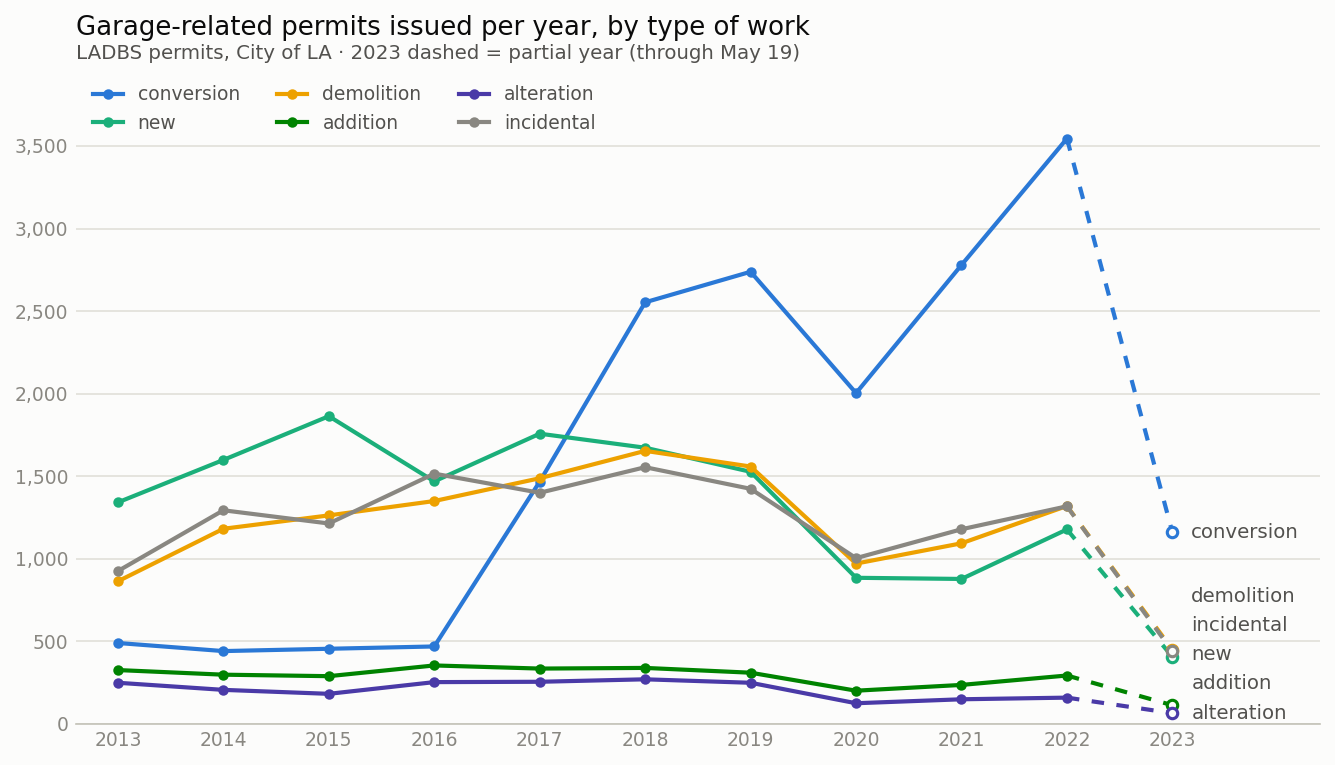

garage_category,conversion,new,demolition,addition,alteration,incidental
year,,,,,,
2013,489,1341,863,325,248,925
2014,440,1598,1181,297,205,1293
2015,454,1863,1262,288,181,1213
2016,468,1468,1349,353,252,1515
2017,1467,1757,1487,334,254,1399
2018,2553,1672,1653,338,269,1554
2019,2738,1526,1558,309,248,1423
2020,2003,884,970,200,124,1003
2021,2779,877,1093,235,148,1178


In [6]:
import matplotlib.pyplot as plt

SURFACE, GRID, BASELINE = "#fcfcfb", "#e1e0d9", "#c3c2b7"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"

CAT_COLORS = {
    "conversion": "#2a78d6",
    "new":        "#1baf7a",
    "demolition": "#eda100",
    "addition":   "#008300",
    "alteration": "#4a3aa7",
    "incidental": "#898781",
}

annual = (
    garage.assign(year=garage.issue_date.dt.year)
    .groupby(["year", "garage_category"]).size()
    .unstack(fill_value=0)
    .reindex(columns=list(CAT_COLORS))
)

fig, ax = plt.subplots(figsize=(9, 5.2), dpi=150, facecolor=SURFACE)
ax.set_facecolor(SURFACE)

LAST_FULL_YEAR = 2022  # data end 2023-05-19: draw the partial year dashed
full = annual.index[annual.index <= LAST_FULL_YEAR]
for cat, color in CAT_COLORS.items():
    s = annual[cat]
    ax.plot(full, s.loc[full], color=color, lw=2, marker="o", ms=4, label=cat)
    ax.plot([LAST_FULL_YEAR, 2023], s.loc[[LAST_FULL_YEAR, 2023]],
            color=color, lw=2, ls=(0, (3, 3)))
    ax.plot(2023, s.loc[2023], marker="o", ms=5, mfc=SURFACE, mec=color, mew=1.5)

# direct labels at the right edge, spread to avoid collisions
ends = sorted([(annual[c].loc[2023], c) for c in CAT_COLORS])
min_gap = annual.values.max() * 0.05
ys = []
for v, c in ends:
    ys.append(v if not ys else max(v, ys[-1] + min_gap))
for (v, c), y in zip(ends, ys):
    ax.annotate(c, xy=(2023, v), xytext=(2023.18, y), va="center",
                fontsize=9.5, color=INK2)

ax.set_xlim(2012.6, 2024.4)
ax.set_ylim(0, annual.values.max() * 1.12)
ax.set_xticks(annual.index)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)

ax.set_title("Garage-related permits issued per year, by type of work",
             loc="left", fontsize=12.5, color=INK, pad=16)
ax.text(0, 1.015, "LADBS permits, City of LA · 2023 dashed = partial year (through May 19)",
        transform=ax.transAxes, fontsize=9.5, color=INK2)
ax.legend(loc="upper left", frameon=False, fontsize=9, ncols=3,
          labelcolor=INK2, handlelength=1.6)

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "garage_permits_annual_by_category.png", facecolor=SURFACE)
plt.show()

annual

In [7]:
# persist the flagged + categorized subset for downstream work
OUT = PERMITS_PARQUET.parent.parent.parent / "02_interm" / "permits_garage.parquet"
OUT.parent.mkdir(parents=True, exist_ok=True)
garage.to_parquet(OUT, index=False)
print(f"wrote {len(garage):,} garage-mention permits -> {OUT}")

wrote 64,340 garage-mention permits -> /Users/adamswietek/Documents/PostDoc/HiddenHousing/data/02_interm/permits_garage.parquet


## Next steps

1. **Tune patterns** — review the per-category samples above, especially `incidental` (false negatives hiding there) and `conversion` (the category we care most about). Descriptions are truncated at ~70 chars, so action verbs can be cut off mid-word.
2. **Validate on a labeled sample** — hand-label ~200 random garage mentions, measure precision/recall per category before trusting counts.
3. **Link to parcels** — this dataset has no APN. Options: (a) address match (`address_start` + `street_name` + `street_suffix` + `zip_code`) against the assessor roll, or (b) pull `yv23-pmwf` (permits with assessor book/page/parcel + lat/lon) and join on `pcis_permit`.
4. **If regex plateaus** — the descriptions are short; an LLM or embedding classifier over the ambiguous residual is cheap at this scale (~60k rows).